# 05 — EDA Block 1: Overview and Temporal Trends

**PACE Phase**: Analyze
**Objective**: answer research questions 1.1–1.5.
Identify the most frequent crimes, analyze yearly trends,
seasonal patterns, and distributions by time slot and day
of the week.

**Input**: `data/processed/crimes_features.parquet`

**Research questions addressed**:
- Q1.1 — Top 5 most frequent crimes and year-over-year trend
- Q1.2 — Top 5 crimes against person vs. against property and trend
- Q1.3 — Categories with the largest YoY growth and decline
- Q1.4 — Seasonal patterns by crime type
- Q1.5 — Time slots and days of the week by LAPD area

In [1]:
import pandas as pd            # Import the Pandas framework for DataFrame manipulation
import numpy as np              # Import the Numpy framework to handle numeric operations
import matplotlib.pyplot as plt # Import Matplotlib for plotting
import seaborn as sns           # Import Seaborn for statistical visualizations

pd.set_option('display.max_rows', None)         # Pandas setting to show all rows with inspection commands
pd.set_option('display.max_columns', None)      # Pandas setting to show all columns with inspection commands
pd.set_option('display.max_info_columns', 200)  # Pandas setting to show info for 200 columns with the '.info()' command

df = pd.read_parquet('../../data/processed/crimes_features.parquet') # Create the variable 'df' containing the
                                                                      # enriched dataset produced by 04_feature_engineering.ipynb
df.shape # Display the number of rows and columns

(3079424, 32)

## 2. Q1.1 — Top 5 most frequent crimes

The 5 offenses with the highest number of occurrences across the entire dataset (2010–2024) 
are identified, then their year-over-year trend is visualized.

In [2]:
df['Crm Cd Desc'].value_counts() # Display the count of records for every crime description, sorted descending

Crm Cd Desc
VEHICLE - STOLEN                                            271661
BATTERY - SIMPLE ASSAULT                                    261872
BURGLARY FROM VEHICLE                                       222893
BURGLARY                                                    202205
THEFT PLAIN - PETTY ($950 & UNDER)                          200671
THEFT OF IDENTITY                                           187848
VANDALISM - FELONY ($400 & OVER, ALL CHURCH VANDALISMS)     168227
INTIMATE PARTNER - SIMPLE ASSAULT                           158201
ASSAULT WITH DEADLY WEAPON, AGGRAVATED ASSAULT              144371
THEFT FROM MOTOR VEHICLE - PETTY ($950 & UNDER)             127823
ROBBERY                                                     114396
VANDALISM - MISDEAMEANOR ($399 OR UNDER)                    114163
THEFT-GRAND ($950.01 & OVER)EXCPT,GUNS,FOWL,LIVESTK,PROD    108460
SHOPLIFTING - PETTY THEFT ($950 & UNDER)                     78009
CRIMINAL THREATS - NO WEAPON DISPLAYED            

In [3]:
top5_filter = ['VEHICLE - STOLEN', 'BATTERY - SIMPLE ASSAULT', 'BURGLARY FROM VEHICLE', 'BURGLARY', 'THEFT PLAIN - PETTY ($950 & UNDER)']
# List of the 5 most frequent crime descriptions, taken from the '.value_counts()' output above

top5_df = df[df['Crm Cd Desc'].isin(top5_filter)] # Keep only the records belonging to the top 5 crimes

top5_grouped = top5_df.groupby(
    ['year', 'Crm Cd Desc']).size().reset_index(name='count') # Count occurrences per year and crime type

top5_grouped.head(5) # Display the first 5 rows to check the aggregation

,year,Crm Cd Desc,count
0,2010,BATTERY - SIMPLE ASSAULT,20527
1,2010,BURGLARY,16086
2,2010,BURGLARY FROM VEHICLE,17705
3,2010,THEFT PLAIN - PETTY ($950 & UNDER),11139
4,2010,VEHICLE - STOLEN,16684


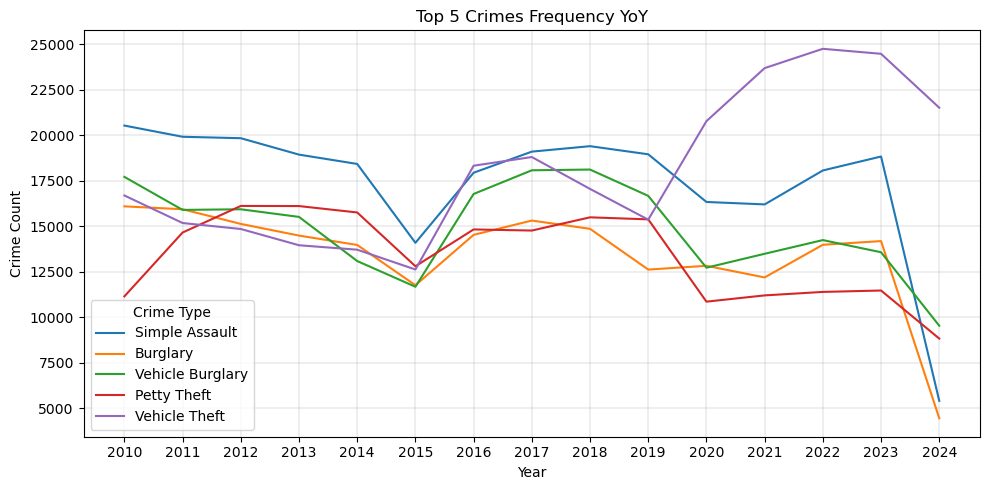

In [4]:
short_names = {
    'VEHICLE - STOLEN': 'Vehicle Theft',
    'BATTERY - SIMPLE ASSAULT': 'Simple Assault',
    'BURGLARY FROM VEHICLE': 'Vehicle Burglary',
    'BURGLARY': 'Burglary',
    'THEFT PLAIN - PETTY ($950 & UNDER)': 'Petty Theft'
} # Abbreviated names for readability in the legend

top5_grouped['crime_short'] = top5_grouped['Crm Cd Desc'].map(short_names) # Map each description to its short label

fig = plt.subplots(figsize=(10,5)) # Create the figure
sns.lineplot(
    x = top5_grouped['year'],
    y = top5_grouped['count'],
    hue = top5_grouped['crime_short'] # One line per crime type
)

plt.legend(title='Crime Type')
plt.title('Top 5 Crimes Frequency YoY')
plt.xlabel('Year')
plt.ylabel('Crime Count')
plt.grid(
    linewidth = 0.3
)
plt.xticks(range(2010, 2025))
plt.savefig('../../outputs/05_eda_block1/01_top5_crimes_trend.png', dpi=150, bbox_inches='tight') # Save the chart to the outputs folder
plt.tight_layout()
plt.show()

### Observations Q1.1

The **5 most frequent crimes** in the analyzed period are:

- Simple Assault
- Burglary
- Vehicle Burglary
- Petty Theft
- Vehicle Theft

The category with the **most consistent increase is Vehicle Theft**, rising **from ~17k** occurrences in 2010 **to ~24k** in 2023, showing sustained and nearly uninterrupted growth from 2019 onwards.

The category with the **most marked decline is Vehicle Burglary**, dropping **from ~17.5k** occurrences in 2010 **to ~13k** in 2023, with a progressive downward trend throughout the analyzed period.

## 3. Q1.2 — Top 5 crimes against person vs. against property

Crimes are split into two macro-categories using the `crime_category` feature created during feature engineering.
For each category we identifythe 5 most frequent offenses and visualize their year-over-year trend.
Goal: understand whether the two categories move together or in diverging directions.

In [5]:
person_vs_property_yearly_df = df[['year', 'crime_category']].copy() # Keep only the columns needed for the aggregation

person_vs_property_yearly_df = (
    person_vs_property_yearly_df
    .groupby(['year', 'crime_category'])
    .agg(count=('crime_category', 'count')) # Count records per year and macro-category
    .reset_index()
)

person_vs_property_yearly_df = person_vs_property_yearly_df[person_vs_property_yearly_df['crime_category'] != 'other']
# Exclude 'other' since the question only concerns person vs. property

person_vs_property_yearly_df.head(10) # Display the first 10 rows to check the aggregation


,year,crime_category,count
1,2010,person,77425
2,2010,property,128082
4,2011,person,74060
5,2011,property,123662
7,2012,person,72536
8,2012,property,126190
10,2013,person,67380
11,2013,property,122702
13,2014,person,71779
14,2014,property,121343


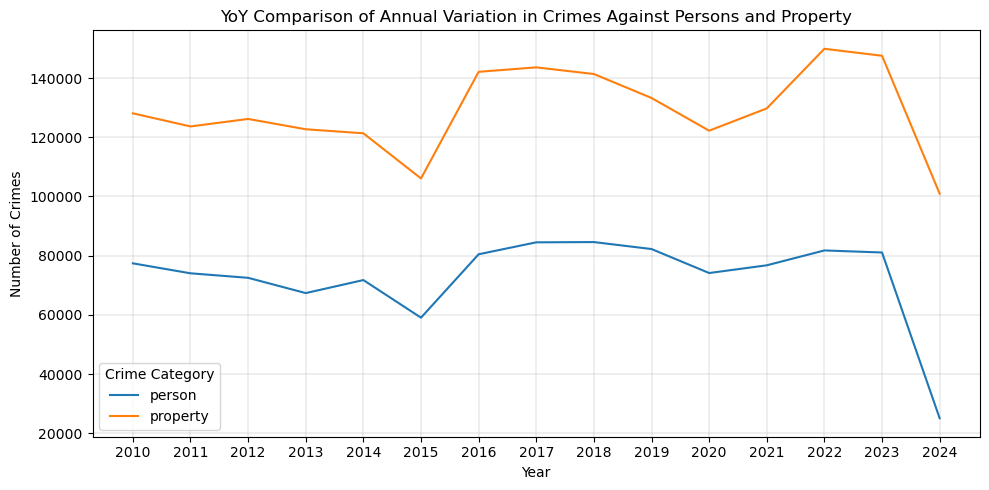

In [6]:
fig = plt.subplots(figsize=(10, 5)) # Create the figure
ax = sns.lineplot(
    x=person_vs_property_yearly_df['year'],
    y=person_vs_property_yearly_df['count'],
    hue=person_vs_property_yearly_df['crime_category'] # One line per macro-category
)

ax.legend(
    title = 'Crime Category',
    loc = 3,
)
plt.title ('YoY Comparison of Annual Variation in Crimes Against Persons and Property')
plt.xlabel('Year')
plt.ylabel('Number of Crimes')
plt.grid(
    linewidth = 0.3
)
plt.xticks(range(2010, 2025))

plt.savefig('../../outputs/05_eda_block1/02_person_vs_property_trend.png', dpi=150, bbox_inches='tight') # Save the chart
plt.tight_layout()
plt.show()

### Observations Q1.2

**Both categories** follow the **same general trend** throughout the analyzed period, **showing parallel movements** across most years.

**Crimes against property consistently account for approximately 60% of the total crime volume**, remaining the dominant category throughout the entire period.

The **property category** reaches its peak volume in 2022 (**~150k** occurrences) and its minimum (excluding the 2015 and 2024 outliers) in 2014 (**~120k** occurrences).

The **person category** reaches its **peak volume between 2017 and 2018** (**~85k** occurrences) and its **minimum in 2013** (**~68k** occurrences).

## 4. Q1.3 — Categories with the largest YoY growth and decline

The crime categories with the largest year-over-year percentage change in the most recent years of the dataset are identified.
Goal: pinpoint emerging crimes (on the rise) and declining crimes, flagging potential shifts
in operational priorities.

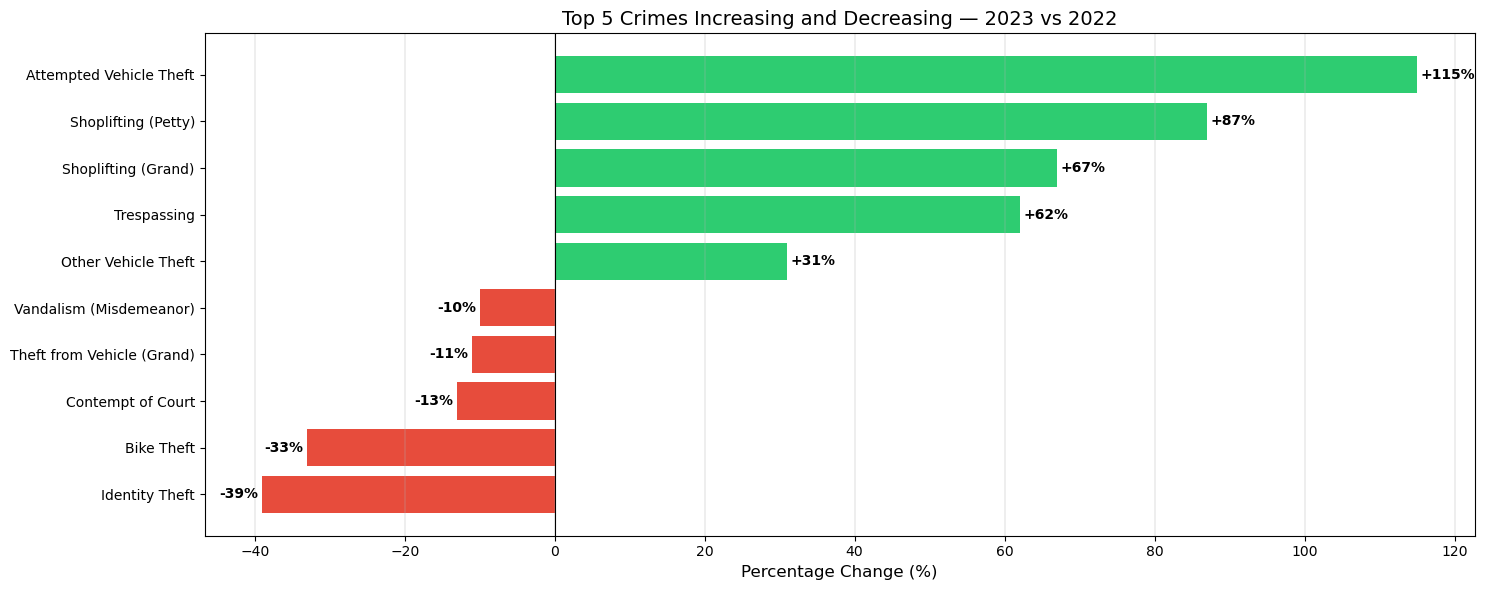

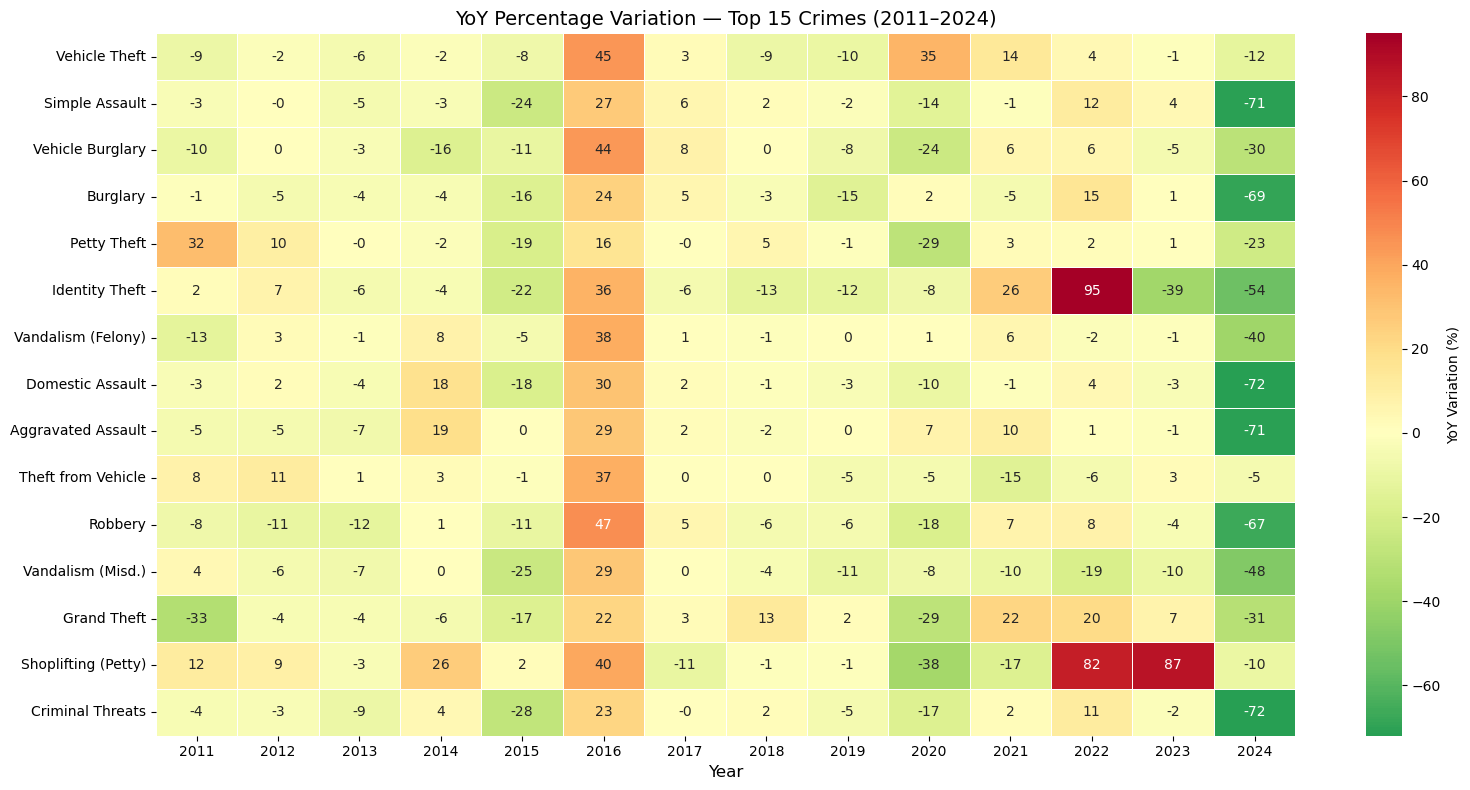

In [7]:
# --- Step 1: Data preparation ---
variationYoY_category_df = df[['year', 'Crm Cd Desc']]
variationYoY_category_df = (
    variationYoY_category_df
        .groupby(['year', 'Crm Cd Desc'])
        .agg(count=('Crm Cd Desc', 'count'))
        .reset_index()
)

variation_pivot_df = variationYoY_category_df.pivot(
    index='year',
    columns='Crm Cd Desc',
    values='count'
)

# Filter: only crimes with >= 500 occurrences in 2022
filter_mask = variation_pivot_df.loc[2022] >= 500
filtered_pivot = variation_pivot_df.loc[:, filter_mask]

# YoY percentage variation
variation = filtered_pivot.pct_change(fill_method=None).round(2)

# --- Step 2: Bar chart — Snapshot 2023 ---
top5 = variation.loc[2023].nlargest(5)
bottom5 = variation.loc[2023].nsmallest(5)
concat_variation = pd.concat([top5, bottom5]).sort_values(ascending=True)

# Abbreviated names for readability
short_names_q13 = {
    'VEHICLE - ATTEMPT STOLEN': 'Attempted Vehicle Theft',
    'SHOPLIFTING - PETTY THEFT ($950 & UNDER)': 'Shoplifting (Petty)',
    'SHOPLIFTING-GRAND THEFT ($950.01 & OVER)': 'Shoplifting (Grand)',
    'TRESPASSING': 'Trespassing',
    'VEHICLE, STOLEN - OTHER (MOTORIZED SCOOTERS, BIKES, ETC)': 'Other Vehicle Theft',
    'THEFT OF IDENTITY': 'Identity Theft',
    'BIKE - STOLEN': 'Bike Theft',
    'CONTEMPT OF COURT': 'Contempt of Court',
    'THEFT FROM MOTOR VEHICLE - GRAND ($950.01 AND OVER)': 'Theft from Vehicle (Grand)',
    'VANDALISM - MISDEAMEANOR ($399 OR UNDER)': 'Vandalism (Misdemeanor)'
}

concat_variation_short = concat_variation.rename(index=short_names_q13)

# Colors: green for growth, red for decline
colors = ['#e74c3c' if v < 0 else '#2ecc71' for v in concat_variation_short.values]

fig, ax = plt.subplots(figsize=(15, 6))
bars = ax.barh(concat_variation_short.index, concat_variation_short.values * 100, color=colors)

# Add labels with the percentage value on each bar
for bar, val in zip(bars, concat_variation_short.values * 100):
    x_pos = bar.get_width()
    offset = 0.5 if x_pos >= 0 else -0.5
    ha = 'left' if x_pos >= 0 else 'right'
    ax.text(x_pos + offset, bar.get_y() + bar.get_height()/2,
            f'{val:+.0f}%', va='center', ha=ha, fontsize=10, fontweight='bold')

ax.set_xlabel('Percentage Change (%)', fontsize=12)
ax.set_ylabel('')
ax.set_title('Top 5 Crimes Increasing and Decreasing — 2023 vs 2022', fontsize=14)
ax.axvline(x=0, color='black', linewidth=0.8)
ax.grid(axis='x', linewidth=0.3)
plt.tight_layout()
plt.savefig('../../outputs/05_eda_block1/03_variation_top5_bottom5_2023.png', dpi=150, bbox_inches='tight')
plt.show()


# --- Step 3: Heatmap — Historical YoY Context ---

# Select the 15 most frequent crimes overall for the heatmap
top15_crimes = df['Crm Cd Desc'].value_counts().head(15).index.tolist()
variation_top15 = variation[top15_crimes].iloc[1:]  # iloc[1:] to exclude the first year (NaN from pct_change)

# Abbreviated names for the heatmap
short_names_heatmap = {
    'VEHICLE - STOLEN': 'Vehicle Theft',
    'BATTERY - SIMPLE ASSAULT': 'Simple Assault',
    'BURGLARY FROM VEHICLE': 'Vehicle Burglary',
    'BURGLARY': 'Burglary',
    'THEFT PLAIN - PETTY ($950 & UNDER)': 'Petty Theft',
    'THEFT OF IDENTITY': 'Identity Theft',
    'VANDALISM - FELONY ($400 & OVER, ALL CHURCH VANDALISMS)': 'Vandalism (Felony)',
    'INTIMATE PARTNER - SIMPLE ASSAULT': 'Domestic Assault',
    'ASSAULT WITH DEADLY WEAPON, AGGRAVATED ASSAULT': 'Aggravated Assault',
    'THEFT FROM MOTOR VEHICLE - PETTY ($950 & UNDER)': 'Theft from Vehicle',
    'ROBBERY': 'Robbery',
    'VANDALISM - MISDEAMEANOR ($399 OR UNDER)': 'Vandalism (Misd.)',
    'THEFT-GRAND ($950.01 & OVER)EXCPT,GUNS,FOWL,LIVESTK,PROD': 'Grand Theft',
    'SHOPLIFTING - PETTY THEFT ($950 & UNDER)': 'Shoplifting (Petty)',
    'CRIMINAL THREATS - NO WEAPON DISPLAYED': 'Criminal Threats'
}

variation_top15 = variation_top15.rename(columns=short_names_heatmap)

# Convert to percentages for visualization
variation_top15_pct = variation_top15 * 100

fig, ax = plt.subplots(figsize=(16, 8))
sns.heatmap(
    variation_top15_pct.T,   # Transposed: crimes on rows, years on columns
    cmap='RdYlGn_r',        # Red = growth (bad), Green = decline (good)
    center=0,
    annot=True,
    fmt='.0f',
    linewidths=0.5,
    cbar_kws={'label': 'YoY Variation (%)'},
    ax=ax
)
ax.set_title('YoY Percentage Variation — Top 15 Crimes (2011–2024)', fontsize=14)
ax.set_xlabel('Year', fontsize=12)
ax.set_ylabel('')
plt.tight_layout()
plt.savefig('../../outputs/05_eda_block1/04_heatmap_yoy_variation_top15.png', dpi=150, bbox_inches='tight')
plt.show()

### Observations Q1.3

The two charts are **complementary and should be read together**. The bar chart shows the **top 5 crimes** with the largest positive and negative changes **between 2022 and 2023** (2024 was excluded due to its anomalous behavior). The heatmap provides a complete **historical overview of YoY changes** across the full analysis period for the **15 highest-volume crimes**.

Both charts reflect the **anomalous behavior of 2015 and the rebound in 2016**, consistent with the introductory methodological note.

The period showing the most significant volume changes is **2019–2023**, with particular attention to **2020**, where — with the exception of Vehicle Theft (**+35%**) — all other categories show significant declines and only negligible increases.

Two cases of particular concern emerge from the heatmap:
- Identity Theft increased by **+95% in 2022**, preceded by a significant **+26%** increase the previous year.
- Shoplifting (Petty) increased by **+82% in 2022**, followed by a further sharp increase of **+87% in 2023**.

**Methodological note**: for the bar chart, only crimes with at least
500 occurrences in 2022 were filtered in, to avoid large percentage
changes on irrelevant volumes (e.g. +1900% on a crime with 1 case)
distorting the results.

## 5. Q1.4 — Seasonal patterns

The monthly distribution of crimes is analyzed to check for the existence
of seasonal patterns. Crimes against the person and against 
property are compared to understand whether the two categories 
follow different seasonal cycles, and specific types are examined in more depth 
(e.g. residential burglary vs. vehicle theft).

**Question**: are there statistically evident seasonal patterns? How do
they differ between macro-categories and specific crime types?

In [8]:
season_pattern_df = (
    df
    .groupby(['year', 'month', 'crime_category'], as_index = False)
    .agg(count=('crime_category', 'count')) # Count records per year, month, and macro-category
)

season_pattern_df = season_pattern_df[season_pattern_df['crime_category'] != 'other'] # Exclude 'other'

print(season_pattern_df.head(15)) # Display the first 15 rows to check the aggregation

    year  month crime_category  count
1   2010      1         person   6970
2   2010      1       property  12193
4   2010      2         person   5836
5   2010      2       property   9874
7   2010      3         person   6677
8   2010      3       property  11087
10  2010      4         person   6512
11  2010      4       property  10922
13  2010      5         person   6864
14  2010      5       property  10503
16  2010      6         person   6970
17  2010      6       property  10418
19  2010      7         person   6793
20  2010      7       property  10765
22  2010      8         person   6528


In [9]:
groupped_season_pattern_df = (
    season_pattern_df
    .groupby(['month', 'crime_category'], as_index=False)
    .agg(mean=('count', 'mean')) # Average the yearly counts for each month/category, smoothing out year-to-year noise
)

print(groupped_season_pattern_df.head(25)) # Display the first 12 rows to check the aggregation

    month crime_category          mean
0       1         person   6296.666667
1       1       property  11635.866667
2       2         person   5595.466667
3       2       property  10208.933333
4       3         person   6202.933333
5       3       property  10928.200000
6       4         person   6058.733333
7       4       property  10548.000000
8       5         person   6263.400000
9       5       property  10788.933333
10      6         person   6187.733333
11      6       property  10574.933333
12      7         person   6409.400000
13      7       property  10893.133333
14      8         person   6409.466667
15      8       property  10876.866667
16      9         person   6128.733333
17      9       property  10453.600000
18     10         person   6257.933333
19     10       property  10976.933333
20     11         person   5568.133333
21     11       property  10514.266667
22     12         person   5489.666667
23     12       property  10850.466667


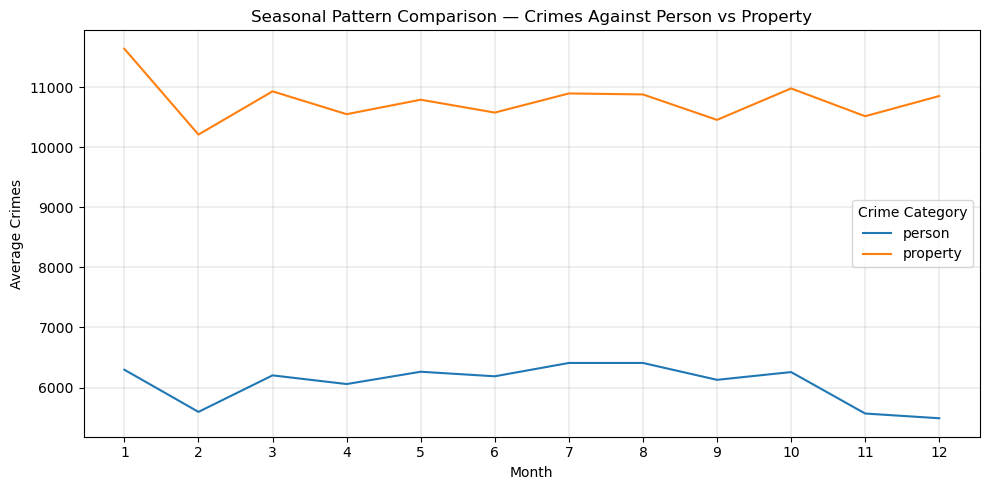

In [10]:
fig = plt.subplots(figsize = (10, 5)) # Create the figure

ax = sns.lineplot(
    groupped_season_pattern_df,
    x = groupped_season_pattern_df['month'],
    y = groupped_season_pattern_df['mean'],
    hue = groupped_season_pattern_df['crime_category'] # One line per macro-category
)

ax.legend(
    title = 'Crime Category'
)
plt.title ('Seasonal Pattern Comparison — Crimes Against Person vs Property')
plt.xlabel('Month')
plt.ylabel('Average Crimes')
plt.grid(
    linewidth = 0.3
)
plt.xticks(range(1, 13))

plt.tight_layout()
plt.savefig('../../outputs/05_eda_block1/05_seasonal_patterns_macro.png', dpi=150, bbox_inches='tight') # Save the chart
plt.show()

### Observations Q1.4 — Part 1: Macro-categories

As observed in the annual variation chart, the **property category consistently shows a higher volume of occurrences** compared to the person category.

- The **person category** reaches its **minimum in December** (5,490) and its **maximum in August** (6,409).
- The **property category** reaches its **minimum in February** (10,209) and its **maximum in January** (11,636).

The two categories show a **notable divergence in December**: while person reaches its annual minimum, property tends to rise compared to the previous month.

### Q1.4 — Part 2: Seasonal deep dive into Property crimes

After the annual maximum in January, crimes against property follow a sawtooth pattern with secondary local peaks in March (10,928) and October (10,976). A deeper analysis of the top 5 Property crimes individually identifies which types drive this shape.

In [11]:
df.head() # Display the first 5 rows to recall the DataFrame's columns before the property deep dive

,DR_NO,Date Rptd,DATE OCC,AREA,AREA NAME,Rpt Dist No,Part 1-2,Crm Cd,Crm Cd Desc,Mocodes,Vict Age,Vict Sex,Vict Descent,Premis Cd,Premis Desc,Weapon Used Cd,Weapon Desc,Status,Status Desc,Crm Cd 1,LOCATION,LAT,LON,hour_occ,year,month,day_of_week,hour_bins,age_group,crime_category,report_delay,is_domestic
0,1307355,2010-02-20,2010-02-20,13,Newton,1385,2,900,VIOLATION OF COURT ORDER,0913 1814 2000,48.0,M,H,501.0,SINGLE FAMILY DWELLING,0.0,No Weapon,AA,Adult Arrest,900.0,300 E GAGE AV,33.9825,-118.2695,13,2010,2,Saturday,Afternoon,Adult,person,0,False
1,11401303,2010-09-13,2010-09-12,14,Pacific,1485,2,740,"VANDALISM - FELONY ($400 & OVER, ALL CHURCH VA...",0329,NaN,M,W,101.0,STREET,0.0,No Weapon,IC,Invest Cont,740.0,SEPULVEDA BL,33.9599,-118.3962,0,2010,9,Sunday,Night,NaN,property,1,False
2,70309629,2010-08-09,2010-08-09,13,Newton,1324,2,946,OTHER MISCELLANEOUS CRIME,0344,NaN,M,H,103.0,ALLEY,0.0,No Weapon,IC,Invest Cont,946.0,1300 E 21ST ST,34.0224,-118.2524,15,2010,8,Monday,Afternoon,NaN,other,0,False
3,90631215,2010-01-05,2010-01-05,6,Hollywood,646,2,900,VIOLATION OF COURT ORDER,1100 0400 1402,47.0,F,W,101.0,STREET,102.0,HAND GUN,IC,Invest Cont,900.0,CAHUENGA BL,34.1016,-118.3295,1,2010,1,Tuesday,Night,Adult,person,0,False
4,100100501,2010-01-03,2010-01-02,1,Central,176,1,122,"RAPE, ATTEMPTED",0400,47.0,F,H,103.0,ALLEY,400.0,"STRONG-ARM (HANDS, FIST, FEET OR BODILY FORCE)",IC,Invest Cont,122.0,8TH ST,34.0387,-118.2488,21,2010,1,Saturday,Late Night,Adult,person,1,False


In [12]:
top5_property = df[df['crime_category'] == 'property']['Crm Cd Desc'].value_counts().head(5).index.tolist()
# List of the 5 most frequent crime descriptions among Property crimes
top5_property

['VEHICLE - STOLEN',
 'BURGLARY FROM VEHICLE',
 'BURGLARY',
 'THEFT PLAIN - PETTY ($950 & UNDER)',
 'THEFT OF IDENTITY']

In [13]:
propertyFocus_df = (
    df
    .groupby(['Crm Cd Desc', 'year', 'month', 'crime_category'], as_index = False)
    .agg(count=('Crm Cd Desc', 'count')) # Count records per crime, year, month and macro-category
)

propertyFocus_df=propertyFocus_df[propertyFocus_df['crime_category'] == 'property'] # Keep only Property crimes
propertyFocus_df['crime_category'].value_counts() # Quick check (result not displayed: not the cell's last statement)

propertyFocus_df = (
    propertyFocus_df
    .groupby(['Crm Cd Desc', 'month'], as_index = False)
    .agg(mean = ('count', 'mean')).round(2) # Average the yearly counts for each crime/month, smoothing out year-to-year noise
)

top5property_filter = propertyFocus_df['Crm Cd Desc'].isin(top5_property) # Boolean mask keeping only the top 5 crimes

filteredProperty_df = propertyFocus_df[top5property_filter].copy()

print(filteredProperty_df['Crm Cd Desc'].nunique())      # Display the number of distinct crimes kept (should be 5)
print('==============')
print(filteredProperty_df['Crm Cd Desc'].unique())        # Display the crime descriptions kept, to check the filter


5
['BURGLARY' 'BURGLARY FROM VEHICLE' 'THEFT OF IDENTITY'
 'THEFT PLAIN - PETTY ($950 & UNDER)' 'VEHICLE - STOLEN']


In [14]:
filteredProperty_df.head() # Display the first 5 rows to check the aggregation

,Crm Cd Desc,month,mean
96,BURGLARY,1,1224.53
97,BURGLARY,2,1068.53
98,BURGLARY,3,1139.60
99,BURGLARY,4,1084.20
100,BURGLARY,5,1141.33


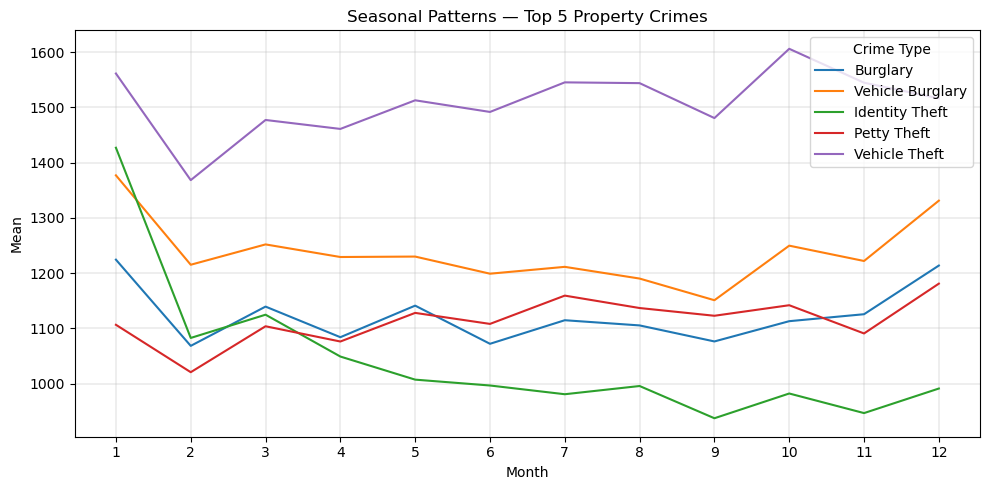

In [15]:
short_names2 = {
    'VEHICLE - STOLEN': 'Vehicle Theft',
    'THEFT OF IDENTITY': 'Identity Theft',
    'BURGLARY FROM VEHICLE': 'Vehicle Burglary',
    'BURGLARY': 'Burglary',
    'THEFT PLAIN - PETTY ($950 & UNDER)': 'Petty Theft'
} # Abbreviated names for readability in the legend

filteredProperty_df['crime_short'] = filteredProperty_df['Crm Cd Desc'].map(short_names2) # Map each description to its short label

fig = plt.subplots(figsize=(10,5)) # Create the figure
sns.lineplot(
    x = filteredProperty_df['month'],
    y = filteredProperty_df['mean'],
    hue = filteredProperty_df['crime_short'] # One line per crime type
)

plt.legend(title='Crime Type')
plt.title('Seasonal Patterns — Top 5 Property Crimes')
plt.xlabel('Month')
plt.ylabel('Mean')
plt.grid(
    linewidth = 0.3
)
plt.xticks(range(1, 13))
plt.tight_layout()
plt.savefig('../../outputs/05_eda_block1/06_seasonal_patterns_property_top5.png', dpi=150, bbox_inches='tight') # Save the chart
plt.show()

### Observations Q1.4 — Part 2: Property crimes deep dive

**Vehicle Theft** is the crime with the highest number of occurrences among the top 5 property crimes. There's a peak in **January** (~ 1,560), then it drops to its **minimum in February** (~ 1,370), then gradually rises to reach its **maximum in October** (~ 1,600).

**Vehicle Burglary** is the second highest-volume crime. It reaches its **maximum in January** (~ 1,380), then shows a **declining trend through September**, from which it begins to recover, reaching a **new peak in December** (~ 1,330).

**Burglary and Petty Theft** show **similar volumes and relatively stable trends** throughout the year, with no significant seasonal peaks.

**Identity Theft** shows a distinctive pattern: it reaches its **maximum in January** (~ 1,430), followed by a **sharp drop in February**, and continues declining to become the **lowest-volume crime from April through December**

## 6. Q1.5 — Time slots and days of the week

The distribution of crimes by time slot and day of the week is analyzed, stratified by macro-category (Person vs Property).
Goal: identify the most critical time windows and understand whether
the patterns differ between the two categories.

**Question**: which time slots and days of the week see the highest
concentration of crimes? Do the patterns differ between crimes against
the person and against property?

In [16]:
hour_distribution_df = (
    df
    .groupby(['hour_bins', 'day_of_week', 'crime_category'], as_index = False, observed = True)
    .agg(counts=('crime_category', 'count')) # Count records per time slot, day of week, and macro-category
).copy()

print(hour_distribution_df.head()) # Display the first 5 rows to check the aggregation

  hour_bins day_of_week crime_category  counts
0     Night      Friday          other     829
1     Night      Friday         person   18027
2     Night      Friday       property   28452
3     Night      Monday          other     938
4     Night      Monday         person   18696


In [17]:
print(f'The unique values of HOUR BINS are: {hour_distribution_df['hour_bins'].nunique()}')  # Display the number of distinct time slots
print(f'and they are: {hour_distribution_df['hour_bins'].unique()}')                          # Display the time slots themselves
print("==============================================================")
print(f'The unique values of DAY OF WEEK are: {hour_distribution_df['day_of_week'].nunique()}') # Display the number of distinct weekdays
print(f'and they are: {hour_distribution_df['day_of_week'].unique()}')                          # Display the weekdays themselves

The unique values of HOUR BINS are: 6
and they are: ['Night', 'Early Morning', 'Morning', 'Afternoon', 'Evening', 'Late Night']
Categories (6, object): ['Night' < 'Early Morning' < 'Morning' < 'Afternoon' < 'Evening' < 'Late Night']
The unique values of DAY OF WEEK are: 7
and they are: ['Friday' 'Monday' 'Saturday' 'Sunday' 'Thursday' 'Tuesday' 'Wednesday']


In [18]:
hour_distribution_df = hour_distribution_df[hour_distribution_df['crime_category'] != 'other'] # Exclude 'other'

giorni_ordinati = ['Monday', 'Tuesday', 'Wednesday', 'Thursday', 'Friday', 'Saturday', 'Sunday'] # Chronological weekday order
hour_distribution_df['day_of_week'] = pd.Categorical(hour_distribution_df['day_of_week'], categories=giorni_ordinati, ordered=True)
# Turn 'day_of_week' into an ordered category so it sorts chronologically instead of alphabetically
hour_distribution_df = hour_distribution_df.sort_values('day_of_week')

print(hour_distribution_df.head()) # Display the first 5 rows to check the sorting

    hour_bins day_of_week crime_category  counts
46    Morning      Monday         person   25098
67  Afternoon      Monday         person   32825
4       Night      Monday         person   18696
5       Night      Monday       property   27763
68  Afternoon      Monday       property   64281


In [19]:
person_pivot = hour_distribution_df[hour_distribution_df['crime_category'] == 'person'].pivot(
    columns = 'day_of_week',
    index = 'hour_bins',
    values = 'counts'
) # Reshape into a time-slot x weekday matrix for Person crimes, ready for a heatmap

property_pivot = hour_distribution_df[hour_distribution_df['crime_category'] == 'property'].pivot(
    columns = 'day_of_week',
    index = 'hour_bins',
    values = 'counts'
) # Same reshape for Property crimes

print(person_pivot.head())
print('======================')
print(property_pivot.head())

day_of_week    Monday  Tuesday  Wednesday  Thursday  Friday  Saturday  Sunday
hour_bins                                                                    
Night           18696    15175      15406     15520   18027     28763   34062
Early Morning   10833     9941      10110     10219   10636     11192   12112
Morning         25098    24345      24964     24285   24689     23213   22428
Afternoon       32825    33077      33368     32357   33844     31611   31625
Evening         33924    33161      33411     33091   35307     33138   35149
day_of_week    Monday  Tuesday  Wednesday  Thursday  Friday  Saturday  Sunday
hour_bins                                                                    
Night           27763    25511      25635     26078   28452     32542   33902
Early Morning   22702    21828      22312     22695   22655     19681   18268
Morning         49042    48478      48742     47789   50727     40701   35542
Afternoon       64281    63088      64578     63368   70800     

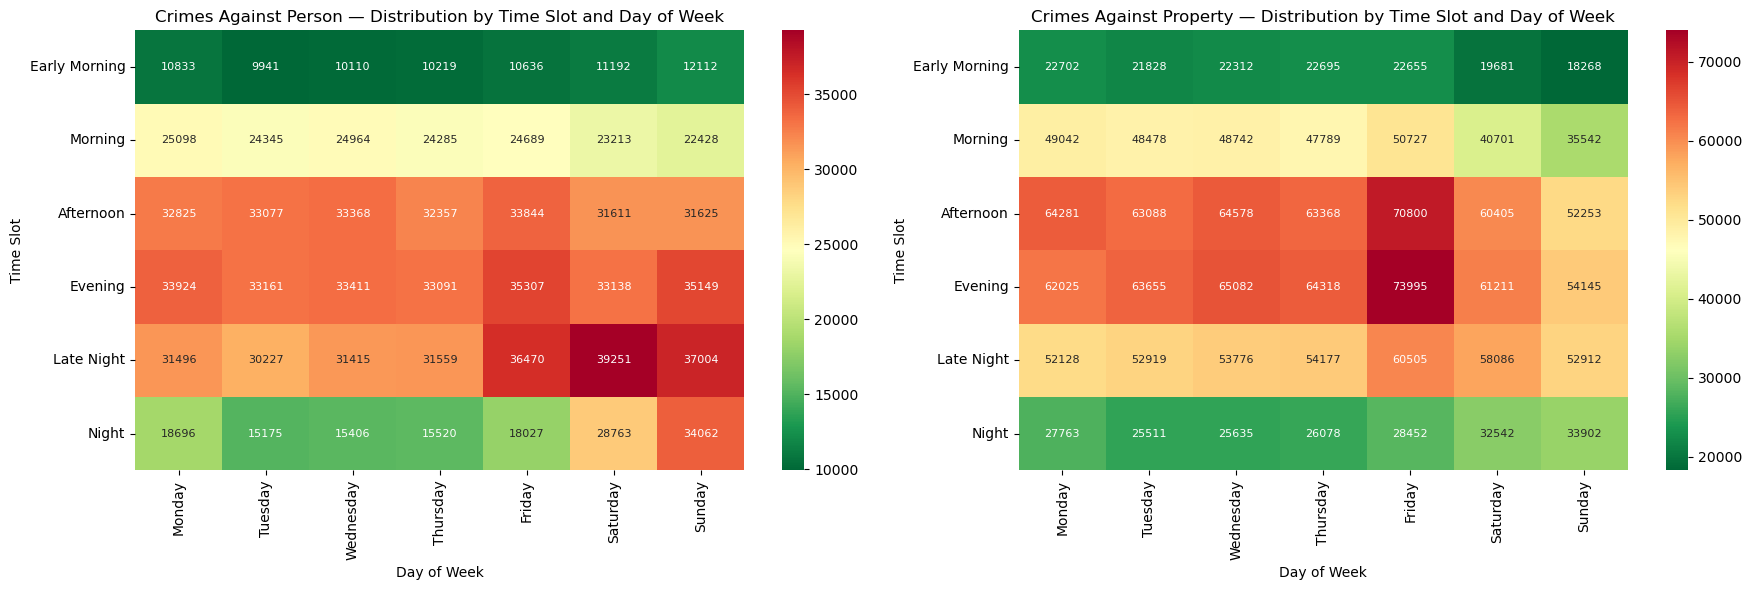

In [20]:
hour_order = ['Early Morning', 'Morning', 'Afternoon', 'Evening', 'Late Night', 'Night'] # Reading order for the heatmap rows

person_pivot = person_pivot.reindex(hour_order)     # Apply the reading order to the Person pivot
property_pivot = property_pivot.reindex(hour_order) # Apply the reading order to the Property pivot

fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(18, 6)) # Two side-by-side subplots, one per macro-category

sns.heatmap(
    person_pivot, ax=ax1, cmap='RdYlGn_r',
    annot=True, fmt='.0f', annot_kws={'size': 8}
)
sns.heatmap(
    property_pivot, ax=ax2, cmap='RdYlGn_r',
    annot=True, fmt='.0f', annot_kws={'size': 8}
)

ax1.set_title('Crimes Against Person — Distribution by Time Slot and Day of Week')
ax2.set_title('Crimes Against Property — Distribution by Time Slot and Day of Week')
ax1.set_xlabel('Day of Week')
ax1.set_ylabel('Time Slot')
ax2.set_xlabel('Day of Week')
ax2.set_ylabel('Time Slot')

ax1.set_yticklabels(ax1.get_yticklabels(), rotation=0, ha='right')
ax2.set_yticklabels(ax2.get_yticklabels(), rotation=0, ha='right')

plt.tight_layout()
plt.savefig('../../outputs/05_eda_block1/07_heatmap_time_distribution_person_vs_property.png', dpi=150, bbox_inches='tight') # Save the chart
plt.show()

### Observations Q1.5 — Distribution by time slot and day of the week

**Time slot reference**: Night 00:00–03:59 | Early Morning 04:00–07:59 | Morning 08:00–11:59 | Afternoon 12:00–15:59 | Evening 16:00–19:59 | Late Night 20:00–23:59

**Early Morning (04:00–07:59) — safest slot**: this is the slot with the lowest values for both categories. For Property, the weekend shows slightly lower values than weekdays (Saturday 19,681, Sunday 18,268 vs ~ 22,000 on weekdays).

**Morning (08:00–11:59) — weekend divergence**: crimes against property drop noticeably on weekends (Saturday 40,701, Sunday 35,542 vs ~ 48,000–50,000 on weekdays). Crimes against person remain comparatively stable across the week.

**Afternoon–Evening (12:00–19:59) — critical slot for both categories**: these two slots concentrate the highest volume of crimes for both Person and Property throughout the entire week. For Property, Friday stands out as the peak day in both slots: Afternoon 70,800 and Evening 73,995 — the highest values recorded across the entire heatmap.

**Late Night (20:00–23:59) — weekend peak for Person**: Friday (36,470), Saturday (39,251) and Sunday (37,004) all show significantly elevated values compared to weekdays (~ 31,000), marking the weekend as the most critical period for this slot.

**Night (00:00–03:59) — Person vs Property divergence**: for Property, the night slot remains relatively uniform throughout the week with only a slight rise on weekends. For Person, a marked weekend peak emerges: Saturday night 28,763 and Sunday night 34,062.